# Phase 4 — Baselines and Ridge

First modeling pass. Establishes two baselines (global mean, hour-of-day mean) plus a Ridge regression with `log1p` target transformation, evaluated with `TimeSeriesSplit(5)`. The metrics tables and figures below are sourced from `reports/metrics.json` produced by `scripts/train_model.py`. This notebook is diagnostic, not part of the runtime pipeline.

## Setup and data load

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit

from bike_sharing.config import load_config
from bike_sharing.models import get_model
from bike_sharing.train import fit_and_cv

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
FIG_DIR = Path(CFG["paths"]["reports_dir"]) / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH = Path(CFG["paths"]["reports_dir"]) / "metrics.json"

sns.set_theme(context="notebook", style="whitegrid")
print("metrics file:", METRICS_PATH)


metrics file: /Users/gokturkberkekorkut/bike-sharing-demand-forecasting/reports/metrics.json


In [2]:
train_path = Path(CFG["paths"]["processed_dir"]) / "train.parquet"
df = pd.read_parquet(train_path).sort_values("datetime").reset_index(drop=True)
y = df["count"].to_numpy(float)
datetime = df["datetime"]
X = df.drop(columns=["count", "datetime"])
print("train rows:", len(df), " feature columns:", X.shape[1])


train rows: 10886  feature columns: 17


## 1. Cross-validation folds

`TimeSeriesSplit` produces five expanding training windows, each followed by a non-overlapping validation window. Earlier folds have less training data; the first fold is the smallest and the least representative of the full data.

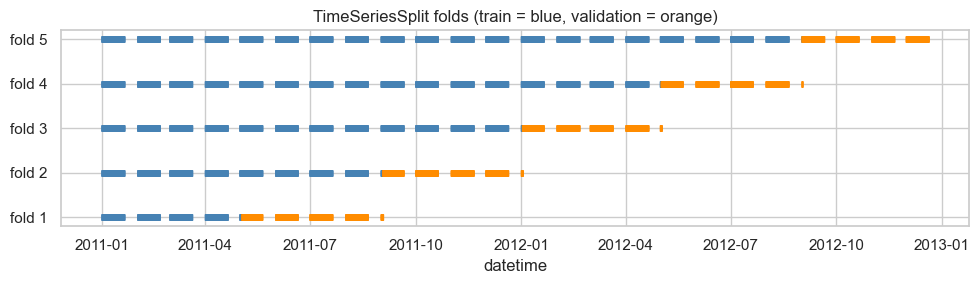

In [3]:
# Visualize the TimeSeriesSplit fold boundaries. Each fold's training
# window grows; each validation window is the next time chunk.
splitter = TimeSeriesSplit(n_splits=CFG["cv"]["n_splits"])
fig, ax = plt.subplots(figsize=(10, 3))
for i, (tr, va) in enumerate(splitter.split(X)):
    ax.plot(datetime.iloc[tr], np.full(len(tr), i), "|", color="steelblue", markersize=4)
    ax.plot(datetime.iloc[va], np.full(len(va), i), "|", color="darkorange", markersize=4)
ax.set_yticks(range(CFG["cv"]["n_splits"]))
ax.set_yticklabels([f"fold {i+1}" for i in range(CFG["cv"]["n_splits"])])
ax.set_title("TimeSeriesSplit folds (train = blue, validation = orange)")
ax.set_xlabel("datetime")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_cv_folds.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. CV metric comparison

RMSLE is the primary score (it matches Kaggle's grading). RMSE, MAE, and R² are diagnostic only. Lower RMSLE is better.

In [4]:
# Load the metrics table written by scripts/train_model.py and compare.
metrics = json.loads(METRICS_PATH.read_text())
rows = []
for name, summary in metrics.items():
    rows.append({"model": name, **summary["mean"], "rmsle_std": summary["std"]["rmsle"]})
table = (
    pd.DataFrame(rows)
    .set_index("model")
    [["rmsle", "rmsle_std", "rmse", "mae", "r2"]]
    .sort_values("rmsle")
)
table.round(3)


,rmsle,rmsle_std,rmse,mae,r2
model,,,,,
hourly_mean_baseline,0.739,0.098,142.972,99.341,0.348
ridge,0.987,0.098,168.895,115.232,0.109
mean_baseline,1.402,0.071,196.381,149.341,-0.206


## 3. Per-fold RMSLE

Per-fold scores expose instabilities that an average can hide. Single-fold pathologies often signal a feature distribution shift between train and validation. A clean linear baseline should trend smoothly from fold 1 to fold 5; sharp spikes earn an investigation.

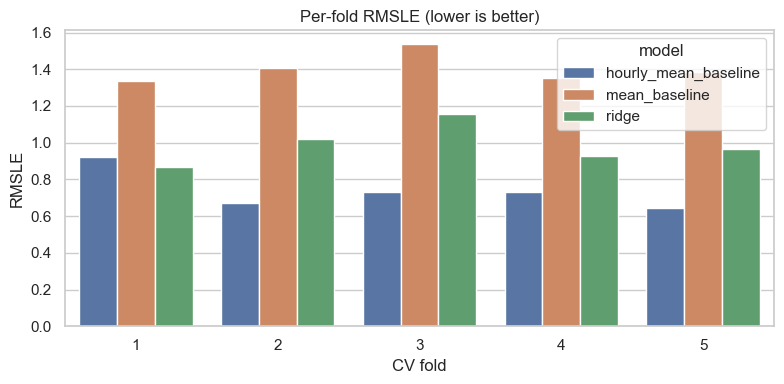

In [5]:
# Per-fold RMSLE for the three models. Helps spot single-fold pathologies.
fold_records = []
for name, summary in metrics.items():
    for i, f in enumerate(summary["folds"]):
        fold_records.append({"model": name, "fold": i + 1, "rmsle": f["rmsle"]})
fold_df = pd.DataFrame(fold_records)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=fold_df, x="fold", y="rmsle", hue="model", ax=ax)
ax.set_title("Per-fold RMSLE (lower is better)")
ax.set_xlabel("CV fold")
ax.set_ylabel("RMSLE")
ax.legend(title="model")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_per_fold_rmsle.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Ridge residuals by hour

First-harmonic cyclic features (`hour_sin`, `hour_cos`) plus `workingday` cannot represent two different hourly curves at once. The Phase 3 review predicted this; the residual plot below makes it visible: Ridge underestimates the morning + evening commuter rush on working days and overpredicts midday/night demand. The hourly-mean baseline has zero structural problem with this shape, which is why it currently outperforms Ridge.

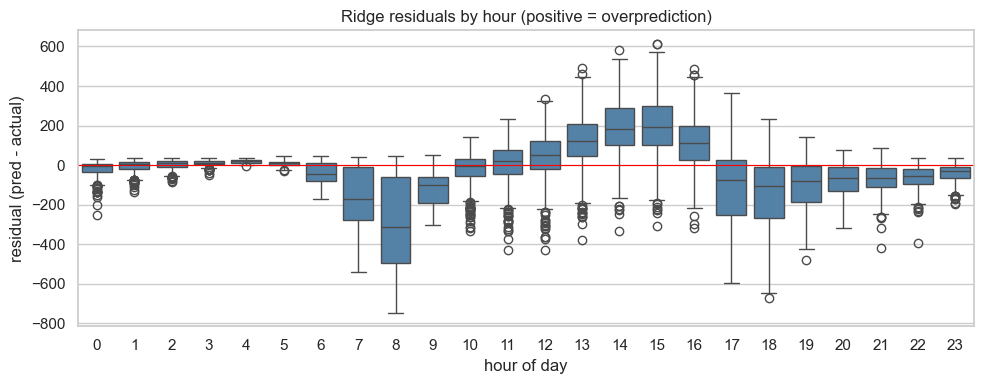

In [6]:
# Refit the three models on the full train set and look at residuals on
# the same data (not a leakage test - this is for shape-of-error
# diagnostics, not generalization).
trained = {}
preds = {}
for name in ("mean_baseline", "hourly_mean_baseline", "ridge"):
    model = get_model(name, CFG).fit(X, y)
    trained[name] = model
    preds[name] = model.predict(X)

resid_df = pd.DataFrame({"hour": df["hour"], "weather": df["weather"], "y": y})
for name, p in preds.items():
    resid_df[f"resid_{name}"] = p - y

# Residuals by hour (Ridge only - the most informative for the bimodal issue).
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=resid_df, x="hour", y="resid_ridge", color="steelblue", ax=ax)
ax.axhline(0, color="red", linewidth=0.8)
ax.set_title("Ridge residuals by hour (positive = overprediction)")
ax.set_xlabel("hour of day")
ax.set_ylabel("residual (pred - actual)")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_ridge_residuals_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()


## Findings (feed into Phase 4 review and Phase 5 trees)

- `hourly_mean_baseline` is the strongest model so far. The two-peak commuter pattern is exactly what a per-hour mean captures trivially. Ridge with first-harmonic cyclic encoding cannot.
- `ridge` beats `mean_baseline` cleanly on every fold but loses to `hourly_mean_baseline`. This is consistent with the Phase 3 review's prediction; the Ridge feature set was deliberately kept honest (cyclic only, no hour one-hot or hour×workingday interaction) so this gap is informative rather than something to hide.
- The Ridge ColumnTransformer drops the raw ordinal time columns (`hour`, `month`, `dayofweek`, `year`); only cyclic encodings and one-hot `season`/`weather` are exposed to the linear model. This prevented an earlier numerical blow-up in fold 1 where train-month range (1-5) underrepresented val-month range (up to 9).
- Phase 5 (tree models) will use the full feature set including raw ordinals; trees are scale-invariant and benefit from the raw representation.
- Phase 4 review candidates: add `hour × workingday` interaction terms, second-harmonic Fourier features, hour one-hot, or polynomial expansion of cyclic features. Each goes into a `docs/experiments/` plan file before code, per AGENTS.md §7.